In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

qSales = pd.read_csv('qSales_2024.csv')

# **MODEL FOR CHOSEN COMPANY: NINTENDO**

In [ ]:
# change date to datetime type

qSales['datadate'] = pd.to_datetime(qSales['datadate'])

In [ ]:
# filter for nintendo

nintendo_sales = qSales.loc[qSales['tic'] == 'NTDOY'].dropna(subset = ['saleq']).reset_index(drop = True)
display(nintendo_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,102450,2001-03-31,2000,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2001Q1,2000Q4,3727.39,A
1,102450,2002-03-31,2001,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2002Q1,2001Q4,4181.51,A
2,102450,2003-03-31,2002,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2003Q1,2002Q4,4269.80,A
3,102450,2004-03-31,2003,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2004Q1,2003Q4,4899.13,A
4,102450,2004-06-30,2004,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2004Q2,2004Q1,750.74,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
79,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
80,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
81,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


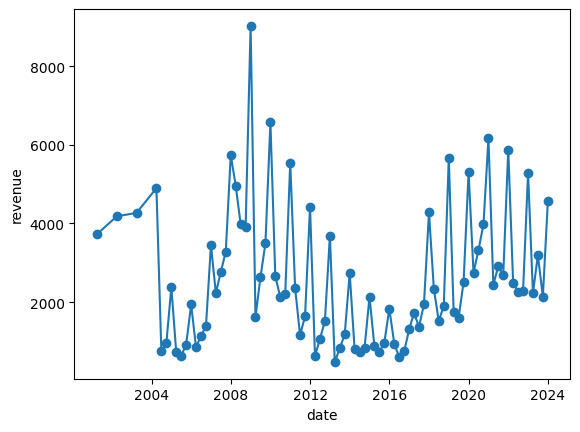

In [ ]:
# visualization of nintendo's revenue over time

plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(nintendo_sales['datadate'], nintendo_sales['saleq'], marker = 'o')

In [ ]:
# add a new column - call it time - and measure incrementally increasing time periods (1,2,3,...)

nintendo_sales['time'] = range(1, len(nintendo_sales) + 1)

In [ ]:
# dummy variable 1: Holiday Quarter = fqtr = 3
# dummy variable 2: Nintendo Switch release  = launched mar 2017, date >= 2017-03

nintendo_sales['holiday_dv'] = np.where(nintendo_sales['fqtr'] == 3, 1, 0)
nintendo_sales['switch_dv'] = np.where(nintendo_sales['datadate'] >= '2017-03-01', 1, 0)

In [ ]:
# creating interaction terms of time * dummy variable

nintendo_sales['holiday_interaction'] = nintendo_sales['time'] * nintendo_sales['holiday_dv']
nintendo_sales['switch_interaction'] = nintendo_sales['time'] * nintendo_sales['switch_dv']

In [ ]:
# separate into training and testing using 75/25
dt4training = nintendo_sales[:int(0.75 * len(nintendo_sales))] # takes the first 75% of rows
dt4testing = nintendo_sales[int(0.75 * len(nintendo_sales)):] # takes the last 25% of rows

In [ ]:
# train our model

x = dt4training.loc[:,['time','holiday_dv','switch_dv','holiday_interaction','switch_interaction']]
y = dt4training.loc[:,'saleq']

x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()
model1.params

,0
const,3007.67
time,-42.32
holiday_dv,2290.91
switch_dv,-3755.20
holiday_interaction,-1.91
switch_interaction,86.26


Nintendo's revenue = 3007.67 − 42.32 * time + 2290.91 * holiday_dv − 3755.20 * switch_dv − 1.91 * holiday_interaction + 86.26 * switch_interaction

In [ ]:
# calculate MAPE score of the model

x_test = dt4testing.loc[:,['time','holiday_dv','switch_dv','holiday_interaction','switch_interaction']]
x_test = sm.add_constant(x_test, has_constant = 'add')

model1_assessment = dt4testing.copy()

model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)

model1_assessment['model1_abs_pct_error'] = abs(
    (
        model1_assessment['saleq'] - model1_assessment['model1_predicted_revenue']
        )/model1_assessment['saleq'])

model1_assessment['model1_abs_pct_error'].mean()

np.float64(0.18830385187770282)

# **MAPE score is 18.83%**

In [ ]:
# to forecast the next 4 quarters
# first prepare the future independent variables (time, dummies, interactions)
# then use the get_prediction function to forecast the values

x_future = pd.DataFrame({
    'time': [84, 85, 86, 87],
    'holiday_dv': [0, 0, 0, 1],
    'switch_dv': [1, 1, 1, 1]
})

x_future['holiday_interaction'] = x_future['time'] * x_future['holiday_dv']
x_future['switch_interaction'] = x_future['time'] * x_future['switch_dv']

x_future = sm.add_constant(x_future, has_constant = 'add')

model1.get_prediction(x_future).summary_frame(alpha = 0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,2943.62,6665.18,-5700.14,11587.37,-5890.38,11777.61
1,2987.56,6930.05,-5999.69,11974.81,-6182.80,12157.92
2,3031.50,7194.97,-6299.32,12362.32,-6475.82,12538.82
3,5199.84,7582.82,-4633.95,15033.64,-4801.58,15201.26


#**MEMO**

We selected Nintendo (NTDOY) as the company of our analysis to create a time series forecasting model of its quarterly revenue to forecast the following 4 quarters using 2 dummy variables, Holiday Season, and Nintento Switch Launch.

We created our model by isolating Nintendo from the qSales dataset, and cleaned the data by removing any NA figures. We then created a time variable for incrementally increasing periods to represent a period of time.

Next, we determined 2 Dummy Variables, where we saw patterns in the time series chart of revenue. 1) Holiday DV and 2) Switch DV. Our Holiday DV represents fiscal quarter 3, as Nintendo's FY end is March, representing the spikes in sales from seasonality. Our Switch DV represents the value from March 2017 onwards, as the massive launch of a new gaming console.

We also created interaction terms by multiplying the time variable with each dummy variable to see  the changes in the revenue trend over time.

The model had a MAPE of 18.83%, which means the forecast was off by about 18.8% on average. This shows the model provides a reasonably good estimate of Nintendo's quarterly revenue.

Finally, the model was used to forecast the next four quarters by creating future values for the time variable, dummy variables, and interaction terms. The model also produced 80% confidence intervals, giving a range where the future revenue is expected to fall.